In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [28]:
load_dotenv()

True

In [29]:
generator_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)
evaluator_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0)
feedback_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [30]:
class EvaluationSchema(BaseModel):
    type: Literal["approved", "needs_improvement"] = Field(description="The evaluation result for the generated post.")
    feedback: str = Field(description="Constructive feedback for improving the post if the evaluation result is 'needs_improvement'.")

In [31]:
structured_evaluation_model = evaluator_model.with_structured_output(EvaluationSchema)

In [ ]:
class PostState(TypedDict):
    topic: str
    post: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iterations: int
    maxiterations: int

In [33]:
def generate_post(state: PostState):
    messages = [
        {
            "role": "system",
            "content": """You are an expert LinkedIn content writer.

Your job is to write a high-quality LinkedIn post based on the given topic and requirements. The post should feel natural, professional, engaging, and valuable to LinkedIn readers.

Follow these rules:
- Write for the target audience provided by the user.
- Keep the post clear, concise, and easy to scan.
- Start with a strong hook.
- Add value, insight, opinion, or practical takeaways.
- Use short paragraphs and line breaks for readability.
- Maintain the requested tone.
- Avoid fluff, repetition, and generic AI-style phrasing.
- Do not mention that you are an AI.
- Do not output explanations or analysis.
- If hashtags are requested, include only relevant hashtags at the end.
- If a call to action is appropriate, include one at the end.

Output only the final LinkedIn post."""
        },
        {
            "role": "user",
            "content": f"""Write a LinkedIn post on the topic: '{state['topic']}'."""
        }
    ]

    post = generator_model.invoke(messages).content

    return { "post": post }

In [34]:
def evaluate_post(state: PostState):
    messages = [
        {
            "role": "system",
            "content": """You are a strict LinkedIn content evaluator.

Your job is to evaluate a LinkedIn post against the following criteria:
- Relevance to the topic
- Clarity and readability
- Engagement quality
- Professional tone
- Value to the reader
- Grammar and writing quality
- Hook strength
- CTA quality, if present
- LinkedIn suitability
- Absence of spammy, vague, or repetitive content

You must decide only one of these outcomes:
- approve
- needs_improvement

Also give the proper feedback for improving the post if the outcome is 'needs_improvement'. Be specific and constructive in your feedback to help improve the post. Do not give generic feedback or say 'the post needs improvement' without details. Focus on actionable suggestions for improvement."""
        },
        {
            "role": "user",
            "content": f"""Evaluate this LinkedIn post for the topic: '{state['topic']}'.

Post:
{state['post']}"""
        }
    ]

    evaluation = structured_evaluation_model.invoke(messages)

    return { "evaluation": evaluation.type, "feedback": evaluation.feedback }

In [35]:
def regenerate_post(state: PostState):
    messages = [
        {
            "role": "system",
            "content": """You are an expert LinkedIn content writer specializing in improving existing posts.

Your task is to regenerate a LinkedIn post using:
1. The original topic
2. The previous version of the post
3. Structured feedback from an evaluator
"""
        },
        {
            "role": "user",
            "content": f"""Regenerate the LinkedIn post using the feedback below.

Topic: '{state['topic']}'

Previous post: '{state['post']}'

Feedback JSON: '{state['feedback']}'
"""
        }
    ]

    post = feedback_model.invoke(messages).content
    iterations = state["iterations"] + 1

    return { "post": post, "iterations": iterations }

In [40]:
def check_condition(state: PostState) -> Literal["approved", "needs_improvement"]:
    if state["evaluation"] == "approved" or state["iterations"] >= state["maxiterations"]:
        return "approved"
    else:
        return "needs_improvement"

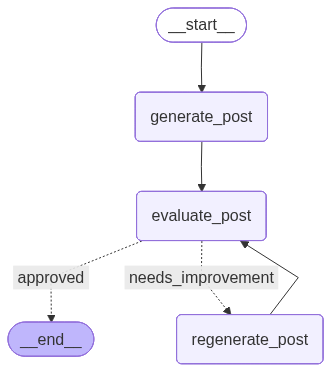

In [37]:
graph = StateGraph(PostState)

graph.add_node("generate_post", generate_post)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("regenerate_post", regenerate_post)

graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "evaluate_post")
graph.add_conditional_edges("evaluate_post", check_condition, { "approved": END, "needs_improvement": "regenerate_post" })
graph.add_edge("regenerate_post", "evaluate_post")

workflow = graph.compile()
workflow

In [38]:
initial_state = {
    "topic": "The future of AI in the workplace"
}

workflow.invoke(initial_state)

{'topic': 'The future of AI in the workplace',
 'post': "Is AI poised to replace human workers, or empower them?\n\nThe narrative around AI in the workplace often swings between fear and hype. But the truth is far more nuanced and, frankly, exciting. We're not headed for a future where robots completely take over, but one where human potential is significantly amplified.\n\nHere's how AI is shaping our professional landscape:\n\n*   **Automation of the Mundane:** AI will increasingly handle the repetitive, data-heavy, and administrative tasks that drain our time and energy, freeing us up for more strategic and creative work.\n*   **Augmentation, Not Replacement:** Think of AI as your intelligent co-pilot. It will enhance human capabilities in areas like data analysis, personalized learning, content generation, and complex problem-solving, making us more efficient and effective.\n*   **Emergence of New Roles:** The integration of AI isn't just about streamlining existing jobs; it's abou

In [43]:
initial_state = {
    "topic": "dafds",
    "maxiterations": 2,
}

workflow.invoke(initial_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 59.607857152s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT